# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

#### Who

* Merchandisers and product recommendation decision makers at a retail company
* People who decide which products get recommended/promoted to customers
* They need actionable insights, not technical details
* Customers benefit in the end, but the direct audience is the business team

#### What

* How combining three data sources (transactions, basket behavior, reviews) reveals buying patterns
* Product associations that can improve recommendation accuracy
* Using multiple signals together gives a more complete picture than any single source

#### How

* Simple, clear visualizations; each one makes one point
* Association charts for product relationships
* Comparison visuals showing patterns across data sources
* Tables for supporting details only
* Focus on clarity so the audience can act on the insights

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [ ]:
SAMPLE_SIZE = 5000 # some of the data sets are large 


   

def load_csv_sampled(filepath, sample_size=SAMPLE_SIZE, random_state=42, sep=None, encoding=None, **kwargs):
    # try encodings in order
    encodings = [encoding] if encoding else ['utf-8', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            # auto-detect delimiter
            if sep is None:
                with open(filepath, 'r', encoding=enc) as f:
                    first_line = f.readline()
                    sep = '\t' if '\t' in first_line else ','
            
            row_count = sum(1 for _ in open(filepath, encoding=enc)) - 1
            
            if sample_size and row_count > sample_size:
                np.random.seed(random_state)
                skip_idx = np.random.choice(range(1, row_count + 1), size=int(row_count * (1 - sample_size/row_count)), replace=False)
                df = pd.read_csv(filepath, skiprows=skip_idx, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows (sampled from {row_count:,}) [encoding: {enc}]")
            else:
                df = pd.read_csv(filepath, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows [encoding: {enc}]")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError(f"Could not decode file with encodings: {encodings}")



In [ ]:
df_us_ecommerce_records_sample = load_csv_sampled("data_us_ecommerce_records.csv")

Loaded 3,312 rows [encoding: latin-1]


In [7]:
# Load Data using default sample 
# instacart is 3Million records so we are just going to use about 50K
df_instacart_sample = load_csv_sampled("data_instacart_combined.csv")



Loaded 5,000 rows (sampled from 33,819,106)


## Summarize the datasets using info() and describe()

In [24]:
def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe())
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe())

print("summarize instacart_sample")
summarize_df(df_instacart_sample)

print("\n")

print("summarize df_us_ecommerce_records_sample")
summarize_df(df_us_ecommerce_records_sample)

summarize instacart_sample
Shape: 5,000 x 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   user_id                 5000 non-null   int64  
 2   order_number            5000 non-null   int64  
 3   order_dow               5000 non-null   int64  
 4   order_hour_of_day       5000 non-null   int64  
 5   days_since_prior_order  4682 non-null   float64
 6   eval_set                5000 non-null   object 
 7   product_id              5000 non-null   int64  
 8   product_name            5000 non-null   object 
 9   aisle_id                5000 non-null   int64  
 10  aisle                   5000 non-null   object 
 11  department_id           5000 non-null   int64  
 12  department              5000 non-null   object 
 13  add_to_cart_order       5000 non-null   int64  


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,aisle_id,department_id,add_to_cart_order,reordered
count,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,4682.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.719884e+06,102380.664000,17.296600,2.714400,13.422800,11.318454,25475.526400,70.663600,9.798200,8.188000,0.589600
std,9.845396e+05,59197.215536,17.544224,2.097645,4.221375,8.945612,14090.293413,38.252423,6.257644,7.031909,0.491956
min,4.330000e+02,27.000000,1.000000,0.000000,0.000000,0.000000,45.000000,1.000000,1.000000,1.000000,0.000000
25%,8.869040e+05,51428.000000,5.000000,1.000000,10.000000,5.000000,13286.250000,31.000000,4.000000,3.000000,0.000000
50%,1.721050e+06,102288.000000,11.000000,2.000000,13.000000,8.000000,25354.000000,83.000000,7.000000,6.000000,1.000000
75%,2.547558e+06,153525.500000,24.000000,5.000000,16.000000,15.000000,37920.000000,107.000000,16.000000,11.000000,1.000000
max,3.421055e+06,206174.000000,100.000000,6.000000,23.000000,30.000000,49683.000000,134.000000,21.000000,53.000000,1.000000


Categorical


,eval_set,product_name,aisle,department
count,5000,5000,5000,5000
unique,2,2796,129,21
top,prior,Banana,fresh fruits,produce
freq,4804,90,563,1486




summarize df_us_ecommerce_records_sample
Shape: 3,312 x 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount  

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000
mean,5087.107488,56186.515097,221.381418,3.766908,0.156467,28.212340
std,2817.482266,31980.375516,585.257531,2.221776,0.207429,241.864342
min,13.000000,1841.000000,0.444000,1.000000,0.000000,-3839.990400
25%,2655.750000,27978.750000,17.018000,2.000000,0.000000,1.763200
50%,5183.500000,60472.500000,53.810000,3.000000,0.200000,8.296800
75%,7498.250000,90032.000000,205.105700,5.000000,0.200000,28.315125
max,9994.000000,99301.000000,13999.960000,14.000000,0.800000,6719.980800


Categorical


,Order Date,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,3312,3312,3312,3312,3312,3312,3312,3312,3312,3312,3312,3312,3312
unique,322,1687,4,693,3,1,350,47,4,1525,3,17,1511
top,02-09-20,CA-2017-100111,Standard Class,SV-20365,Consumer,United States,New York City,California,West,FUR-CH-10003774,Office Supplies,Binders,Easy-staple paper
freq,36,14,1897,20,1668,3312,306,663,1095,8,2002,500,16


## Are there any duplicate rows?

In [ ]:
def check_dup_rows(df):
    dups = df.duplicated().sum()
    print(f"Duplicate rows: {dups:,} ({dups/len(df)*100:.2f}%)")
    if dups > 0:
        display(df[df.duplicated(keep=False)].head(10))
    return dups



print("duplicate row checks instacart_sample")
check_dup_rows(df_instacart_sample)

print("\n")

print("duplicates row checks df_us_ecommerce_records_sample")
check_dup_rows(df_us_ecommerce_records_sample)

duplicate checks instacart_sample
Duplicate rows: 0 (0.00%)


duplicates checks df_us_ecommerce_records_sample
Duplicate rows: 0 (0.00%)


np.int64(0)

## Are there any duplicate values in a given column (when this would be inappropriate?)

- Yes, there are duplicates — expected in denormalized data
- Categorical columns naturally have fewer unique values (that's fine)
- Id columns like `orderId` repeats per product line item, so order-level IDs aren't useful as features since they're just arbitrary identifiers


duplicate column checks instacart_sample


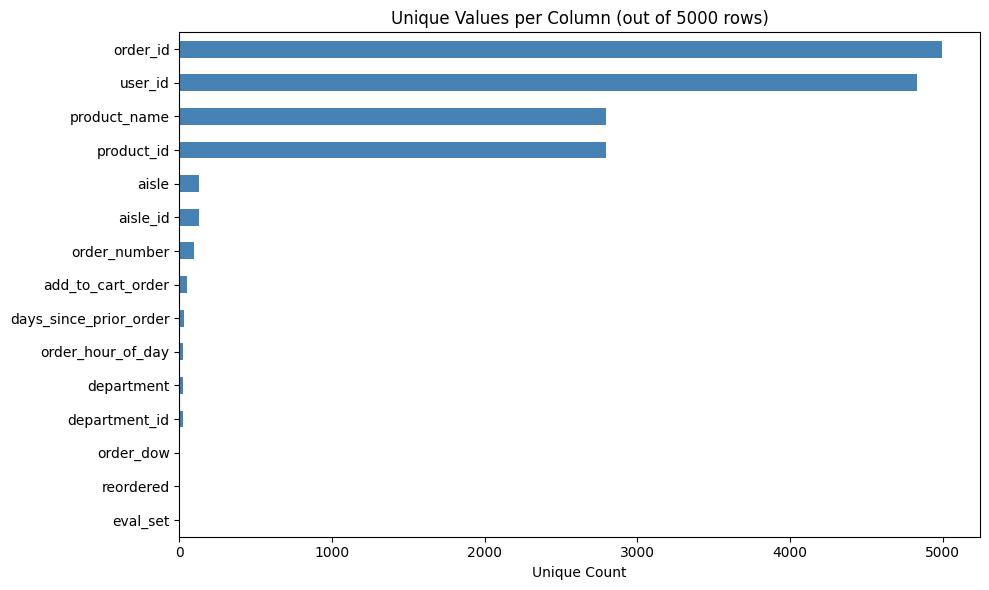

                        Unique Count  Total Row Count
eval_set                           2             5000
reordered                          2             5000
order_dow                          7             5000
department_id                     21             5000
department                        21             5000
order_hour_of_day                 24             5000
days_since_prior_order            31             5000
add_to_cart_order                 51             5000
order_number                      97             5000
aisle_id                         129             5000
aisle                            129             5000
product_id                      2796             5000
product_name                    2796             5000
user_id                         4829             5000
order_id                        4994             5000


duplicates column checks df_us_ecommerce_records_sample


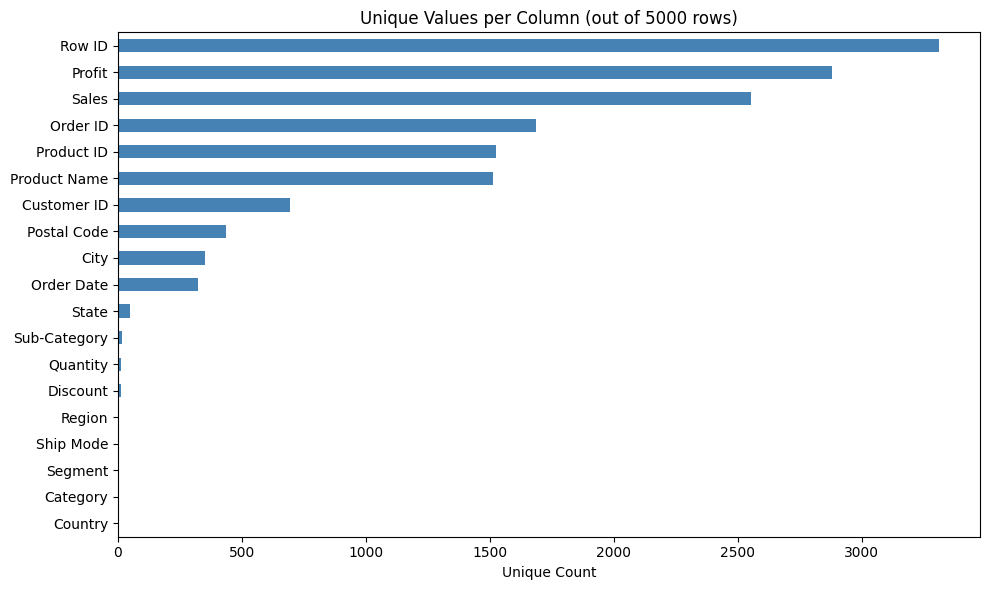

              Unique Count  Total Row Count
Country                  1             3312
Category                 3             3312
Segment                  3             3312
Ship Mode                4             3312
Region                   4             3312
Discount                12             3312
Quantity                14             3312
Sub-Category            17             3312
State                   47             3312
Order Date             322             3312
City                   350             3312
Postal Code            437             3312
Customer ID            693             3312
Product Name          1511             3312
Product ID            1525             3312
Order ID              1687             3312
Sales                 2552             3312
Profit                2881             3312
Row ID                3312             3312


In [33]:
import matplotlib.pyplot as plt
def check_dup_values(df):
    unique_counts = df.nunique()
    # Get the total row count
    total_rows = df.shape[0]

    # Create a new DataFrame with the results
    summary_df = pd.DataFrame({
        'Unique Count': unique_counts,
        'Total Row Count': total_rows
    })

    # Display the summary DataFrame
    summary_df.sort_values('Unique Count', inplace=True)
    summary_df['Unique Count'].plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.xlabel('Unique Count')
    plt.title('Unique Values per Column (out of 5000 rows)')
    plt.tight_layout()
    plt.show()
    print(summary_df)

print("duplicate column checks instacart_sample")
check_dup_values(df_instacart_sample)

print("\n")

print("duplicates column checks df_us_ecommerce_records_sample")
check_dup_values(df_us_ecommerce_records_sample)

## What are the mean, median, and mode of each column?

In [ ]:
def comput_basic_stats(df, columns):
   print("\n")
   print(f"Median\n\n{df[columns].median()}")
   print("\n")
   print(f"Mode\n\n{df[columns].mode()}")
   print("\n")
   print(f"Mean\n\n{df[columns].mean()}")

print("basic stats  df_us_ecommerce_records_sample")
stat_columns=['Sales', 'Quantity', 'Discount', 'Profit']
comput_basic_stats(df_us_ecommerce_records_sample, stat_columns)



basic stats  df_us_ecommerce_records_sample


Median

Sales       53.8100
Quantity     3.0000
Discount     0.2000
Profit       8.2968
dtype: float64


Mode

   Sales  Quantity  Discount  Profit
0  12.96         2       0.0     0.0


Mean

Sales       221.381418
Quantity      3.766908
Discount      0.156467
Profit       28.212340
dtype: float64


## Are there any missing or null values?

- Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

Yes there some null values but nothing that is major.

- In the us_ecommerce_records dataset, there are no null values—though it's also a smaller dataset at around 3,500 rows.

- In the instacart_sample dataset (5,000 sampled rows), only one column has nulls: days_since_prior_order. 

  - Null is actually a valid value here since it represents first-time orders. 
We could fill it with the maximum value if needed, but I think it's fine to leave as-is.

## Encode any categorical variables (e.g. with one-hot encoding.)


Yes, there are multiple categorical columns that can be one-hot encoded. 

Here are some examples I am useing
- In the Instacart dataset: `department`
- In the US e-commerce dataset: `Category`

In [59]:
def one_hot_encode(df, columns):
     return pd.get_dummies(df, columns=columns, dtype=int)

# Perform one-hot encoding using pandas get_dummies
one_hot_encoded_df = one_hot_encode(df_us_ecommerce_records_sample, columns=['Category'])
one_hot_encoded_df.head()

df_us_ecommerce_records_sample.columns

Index(['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

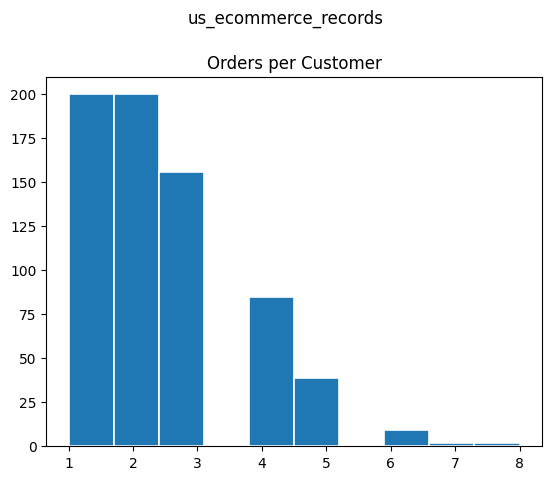

In [83]:
df = df_us_ecommerce_records_sample
df.groupby('Customer ID')['Order ID'].nunique().hist(edgecolor='white', linewidth=1.2)
plt.title('Orders per Customer')
plt.suptitle('us_ecommerce_records', y=1.02)
plt.grid(False)
plt.show()



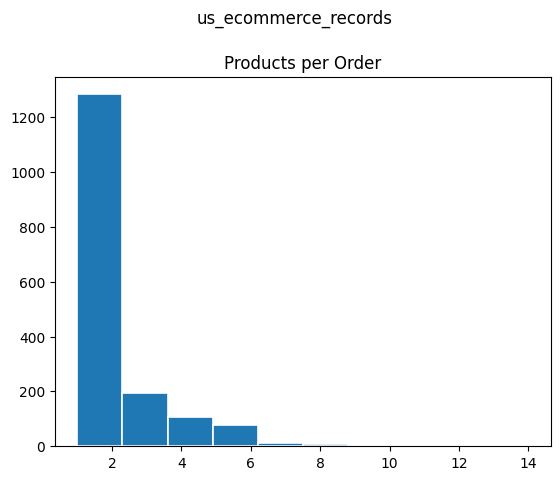

In [84]:
# Products per order, This is Important for recommendtion 
_ = df.groupby('Order ID')['Product Name'].count().hist(edgecolor='white', linewidth=1.2)
plt.title('Products per Order')
plt.grid(False)
plt.suptitle('us_ecommerce_records', y=1.02)
plt.show()

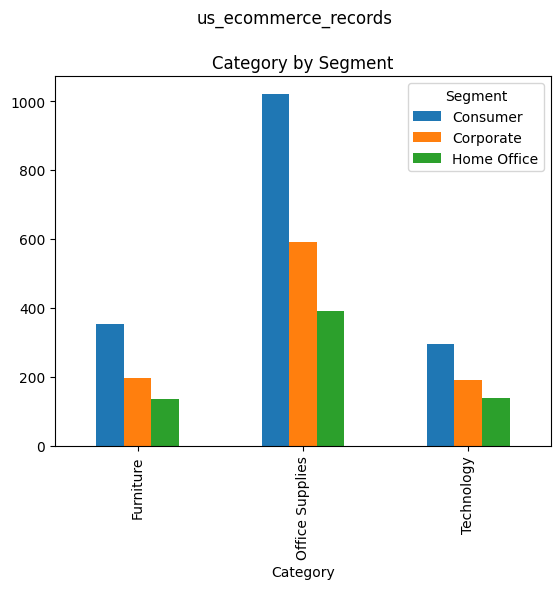

In [85]:
# Category by Segment
_ = pd.crosstab(df['Category'], df['Segment']).plot(kind='bar')
plt.suptitle('us_ecommerce_records', y=1.02)
plt.title('Category by Segment')
plt.show()

Text(0.5, 1.02, 'Instacart')

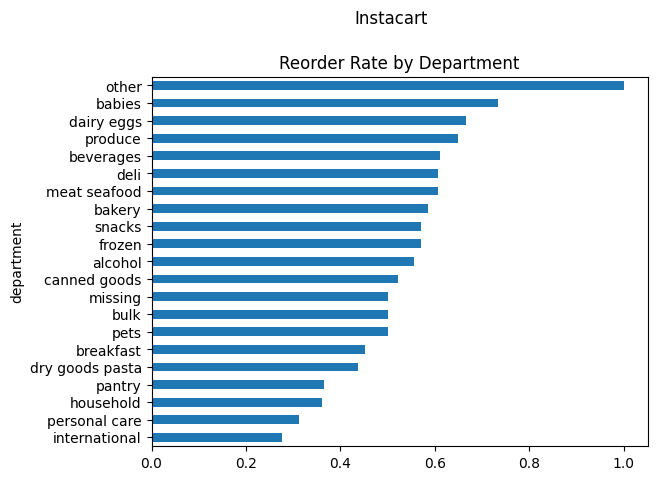

In [86]:
# Orders per user
df = df_instacart_sample

df.groupby('department')['reordered'].mean().sort_values().plot(kind='barh')
plt.grid(False)
plt.title('Reorder Rate by Department')
plt.suptitle('Instacart', y=1.02)


Text(0.5, 1.02, 'Instacart')

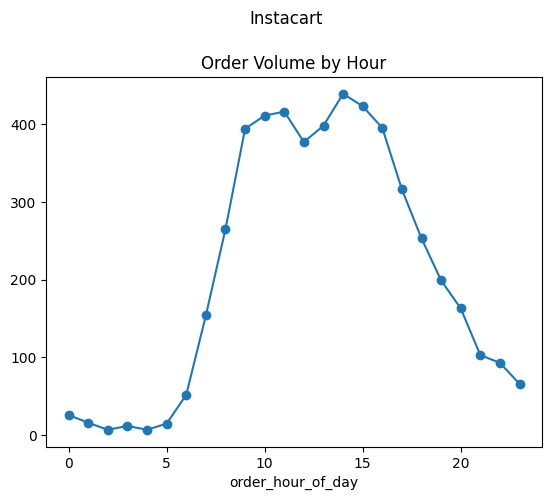

In [89]:
df['order_hour_of_day'].value_counts().sort_index().plot(kind='line', marker='o')
plt.grid(False)
plt.title('Order Volume by Hour')
plt.suptitle('Instacart', y=1.02)